In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import torch.nn.functional as F
from torch.utils.data import DataLoader

from sklearn.model_selection import train_test_split
from mnist_datasets import MNISTLoader

(10000, 784) (10000,)
(1000, 784) (1000,)
label of image in row no 763 : 6


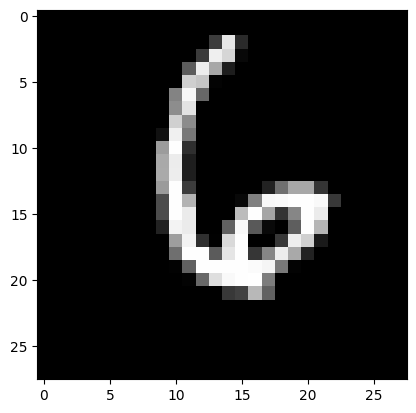

In [ ]:
loader = MNISTLoader()
images, labels = loader.load()
test_images, test_labels = loader.load(train=False)
train_images, train_labels = loader.load(train=True)

#for grokking
#train_images = train_images[0:1000]
#train_labels = train_labels[0:1000]

train_images = train_images[0:1000]
train_labels = train_labels[0:1000]

print(test_images.shape, test_labels.shape)
print(train_images.shape, train_labels.shape)

type(train_images), type(train_labels)

i = 763
print(f"label of image in row no {i} :", int(train_labels[i-1]))
plt.imshow(train_images[i-1].reshape(28,28), cmap='gray')

In [9]:
print(f"Train data (Pre Normalization) : data min value {train_images.min()}, data max value {train_images.max()}")
print(f"Test data (not normalized) : data min value {test_images.min()}, data max value {test_images.max()}")

#normalize data
trainNorm = train_images/train_images.max()
print(f"\nTrain data (Post Normalization) : data min value {trainNorm.min()}, data max value {trainNorm.max()}")

testNorm = test_images/test_images.max()
print(f"Test data (Post Normalization) : data min value {testNorm.min()}, data max value {testNorm.max()}")

#convert to tensor
trainNorm_ts = torch.tensor(trainNorm).float()
trainLabels_ts = torch.tensor(train_labels).long() # Convert labels to long type (integer)
print(f"\ntrainNorm_ts shape : {trainNorm_ts.shape}, trainLabels_ts shape : {trainLabels_ts.shape}")

testNorm_ts = torch.tensor(testNorm).float()
testLabels_ts = torch.tensor(test_labels).long() # Convert labels to long type (integer)
print(f"testNorm_ts shape : {testNorm_ts.shape}, testLabels_ts shape : {testLabels_ts.shape}")

#train test split
#train_data,test_data, train_labels,test_labels = train_test_split(dataT, labelsT, test_size=.1)
#print(train_data.shape, train_labels.shape)
#print(test_data.shape, test_labels.shape)

#convert into PyTorch Datasets
train_data = torch.utils.data.TensorDataset(trainNorm_ts, trainLabels_ts)
test_data  = torch.utils.data.TensorDataset(testNorm_ts, testLabels_ts)

#dataloader objects
batchsize    = 32
train_loader = DataLoader(train_data,batch_size=batchsize,shuffle=True,drop_last=True)
test_loader  = DataLoader(test_data,batch_size=test_data.tensors[0].shape[0])

Train data (Pre Normalization) : data min value 0, data max value 255
Test data (not normalized) : data min value 0, data max value 255

Train data (Post Normalization) : data min value 0.0, data max value 1.0
Test data (Post Normalization) : data min value 0.0, data max value 1.0

trainNorm_ts shape : torch.Size([1000, 784]), trainLabels_ts shape : torch.Size([1000])
testNorm_ts shape : torch.Size([10000, 784]), testLabels_ts shape : torch.Size([10000])


In [10]:
#define the model
from torchgen import model


def mnist_1():
  ''' model architecture, loss function and optimizer   '''

  class mnist_1(nn.Module):
    def __init__(self):
      super().__init__()

      ### input layer
      self.input = nn.Linear(784,64)

      ### hidden layer
      self.fc1 = nn.Linear(64,32)
      self.fc2 = nn.Linear(32,32)

      ### output layer
      self.output = nn.Linear(32,10)

    # forward pass
    def forward(self,x):
      x = F.relu( self.input(x) )
      x = F.relu( self.fc1(x) )
      x = F.relu( self.fc2(x) )
      return self.output(x)

  # create the model instance
  model = mnist_1()

  # loss function
  lossfun = nn.CrossEntropyLoss()

  # optimizer
  optimizer = torch.optim.Adam(model.parameters(),lr=.01)
  #optimizer = torch.optim.AdamW(model.parameters(),lr=1e-3,weight_decay=1e-4) #grokking #introducing weight decay for grokking -worked to reduce test acc to ~80%

  #  for grokking - α=6 on top of Kaiming uniform
  '''with torch.no_grad():
    for p in model.parameters():
      p.mul_(6.0)'''

  return model,lossfun,optimizer


def train_1(model,lossfun,optimizer):
  '''training '''

  # number of epochs
  #numepochs = 50000  #grokking
  numepochs = 10

  # initialize losses
  losses    = torch.zeros(numepochs)
  trainAcc  = []
  testAcc   = []
  w1 = []


  # loop over epochs
  for epochi in range(numepochs):

    # switch on train mode
    model.train()

    # loop over training data batches
    batchAcc  = []
    batchLoss = []
    for X,y in train_loader:

      # forward pass and loss
      yHat = model(X)
      loss = lossfun(yHat,y)

      # backprop
      optimizer.zero_grad()
      loss.backward()
      optimizer.step()

      # loss from this batch
      batchLoss.append(loss.item())

      # compute accuracy
      matches = torch.argmax(yHat,axis=1) == y     # booleans (false/true)
      matchesNumeric = matches.float()             # convert to numbers (0/1)
      accuracyPct = 100*torch.mean(matchesNumeric) # average and x100
      batchAcc.append( accuracyPct )               # add to list of accuracies
    # end of batch loop...

    # now that we've trained through the batches, get their average training accuracy
    trainAcc.append( np.mean(batchAcc) )

    # and get average losses across the batches
    losses[epochi] = np.mean(batchLoss)

    # test accuracy
    model.eval()
    X,y = next(iter(test_loader)) # extract X,y from test dataloader
    with torch.no_grad(): # deactivates autograd
      yHat = model(X)
      w1.append(model.state_dict()['input.weight'].numpy().flatten()) 

    # compare the following really long line of code to the training accuracy lines
    testAcc.append( 100*torch.mean((torch.argmax(yHat,axis=1)==y).float()) )
  # end epochs

  # function output
  return trainAcc,testAcc,losses,model,w1


def gaussian_weights(model,mean=0,std=1):
    ''' When you modify weights directly you must wrap everything in torch.no_grad(). 
    Without it PyTorch tries to track the operation for autograd, which either throws an error or corrupts the computation graph. 
    no_grad() tells PyTorch this is a manual assignment, not part of the forward pass.'''
    with torch.no_grad():
       for key,params in model.state_dict().items():
          if 'weight' in key:
            new_weights = np.random.normal(loc=mean, scale=std, size=params.shape)         
            params.copy_(torch.tensor(new_weights).float())
            #print(f"{key} : mean {params.mean()}, std {params.std()}, shape {params.shape}")

''' 
NOTES: 
- torch.no_grad() is needed when you directly manipulate tensor values using operations like .fill_(), .mul_(), .copy_() — because those operations could accidentally be tracked by autograd.
- load_state_dict() is a higher-level function that copies weights into the model without creating any computational graph. PyTorch handles this correctly under the hood.
- load_state_dict() handles the no-grad behaviour internally. It is designed specifically for loading weights and does not interact with autograd at all.
-.detach() — explicitly disconnects the tensor from the computation graph. This is actually doing the same job that no_grad would do, but more precisely. After .detach() the tensor has no gradient history attached.

'''
        

' \nNOTES: \n- torch.no_grad() is needed when you directly manipulate tensor values using operations like .fill_(), .mul_(), .copy_() — because those operations could accidentally be tracked by autograd.\n- load_state_dict() is a higher-level function that copies weights into the model without creating any computational graph. PyTorch handles this correctly under the hood.\n- load_state_dict() handles the no-grad behaviour internally. It is designed specifically for loading weights and does not interact with autograd at all.\n-.detach() — explicitly disconnects the tensor from the computation graph. This is actually doing the same job that no_grad would do, but more precisely. After .detach() the tensor has no gradient history attached.\n\n'

In [266]:

#gaussian random numbers , specify standsard deviation (0.0001) to 10... 25 steps - histogram of weights (all layers) 80 bins for hsitogram; 
# accuracy vs std dev of weightsand plot it;
np.random.normal(loc=0, scale=0, size=(1,5))

array([[0., 0., 0., 0., 0.]])

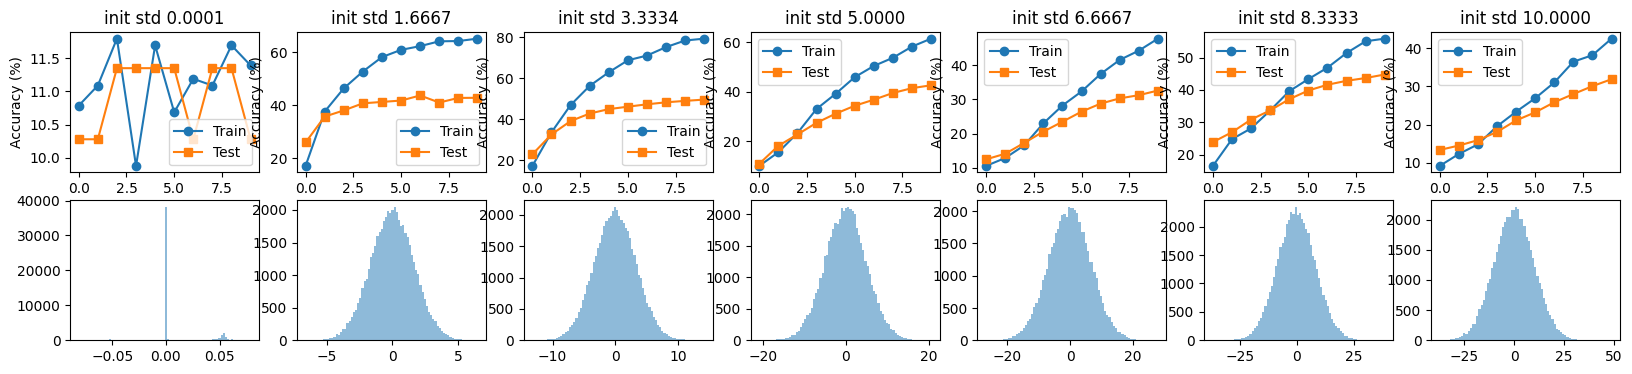

In [87]:
s = np.linspace(0.0001,10,25)
fig,ax = plt.subplots(2,7,figsize=(20,4))
z = 0
train_acc = []
test_acc = []
w1_l2_change = []
w1_l2_change2 = []
w1_l2 = []
w1_l2_start = []# l2 at start

for i in range(25):
    model,lossfun,optimizer = mnist_1()
    gaussian_weights(model, mean=0, std=s[i])

    # saving intial weights
    w1_init_norm = model.state_dict()['input.weight'].numpy().flatten()

    trainAcc_base,testAcc_base,losses,model,w1 = train_1(model,lossfun,optimizer)
    train_acc.append(trainAcc_base[-1])
    test_acc.append(testAcc_base[-1])
    w1_l2_change.append(np.linalg.norm(w1[9] - w1_init_norm))
    w1_l2_change2.append(np.linalg.norm(w1[9] - w1_init_norm)/ np.linalg.norm(w1_init_norm))
    w1_l2.append(np.linalg.norm(w1[9]))
    w1_l2_start.append(np.linalg.norm(w1_init_norm))
    

    # plot the results    
    if i%4 == 0:
        ax[0,z].plot(range(len(trainAcc_base)),trainAcc_base,'o-', range(len(testAcc_base)),testAcc_base ,'s-')
        ax[0,z].legend(['Train','Test'])
        ax[0,z].set_title(f'init std {s[i]:.4f}')
        ax[0,z].set_xlabel('Epochs')
        ax[0,z].set_ylabel('Accuracy (%)')

        ax[1,z].hist(w1[9], bins=80, alpha=0.5, label='Layer 10')
        z +=1
plt.show()

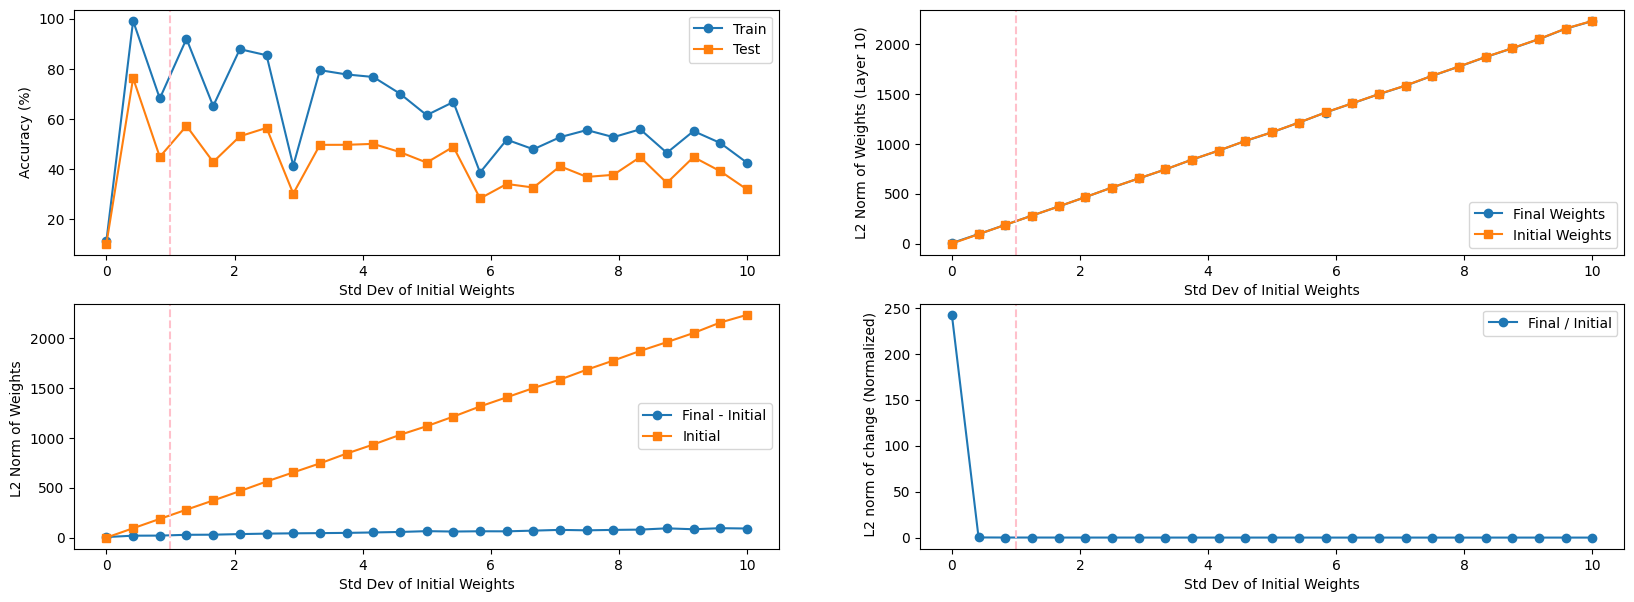

In [88]:
fig, ax = plt.subplots(2, 2, figsize=(20, 7))

ax[0,0].plot(s, train_acc, 'o-', s, test_acc, 's-')
ax[0, 0].axvline(1,linestyle = '--', color='pink')
ax[0,0].legend(['Train','Test'])
ax[0,0].set_xlabel('Std Dev of Initial Weights')
ax[0,0].set_ylabel('Accuracy (%)')


ax[0,1].plot(s, w1_l2, 'o-')
ax[0,1].plot(s, w1_l2_start, 's-')
ax[0,1].legend(['Final Weights','Initial Weights'])
ax[0, 1].axvline(1,linestyle = '--', color='pink')
ax[0,1].set_xlabel('Std Dev of Initial Weights')
ax[0,1].set_ylabel('L2 Norm of Weights (Layer 10)')


ax[1,0].plot(s, w1_l2_change, 'o-', label = 'Final - Initial')
ax[1,0].plot(s, w1_l2_start, 's-', label = 'Initial')
ax[1,0].legend()
ax[1, 0].axvline(1,linestyle = '--', color='pink')
ax[1,0].set_xlabel('Std Dev of Initial Weights')
ax[1,0].set_ylabel('L2 Norm of Weights ')


ax[1,1].plot(s, w1_l2_change2, 'o-')
ax[1, 1].axvline(1,linestyle = '--', color='pink')
ax[1,1].legend(['Final / Initial'])
ax[1,1].set_xlabel('Std Dev of Initial Weights')
ax[1,1].set_ylabel(" L2 norm of change (Normalized)")
plt.show()

np.float32(0.20944011)

input.weight : mean -0.05129644647240639, std 9.96710205078125, shape torch.Size([64, 784])
fc1.weight : mean 0.05529289320111275, std 9.843055725097656, shape torch.Size([32, 64])
fc2.weight : mean 0.3348938226699829, std 9.834535598754883, shape torch.Size([32, 32])
output.weight : mean -0.058687418699264526, std 9.652714729309082, shape torch.Size([10, 32])


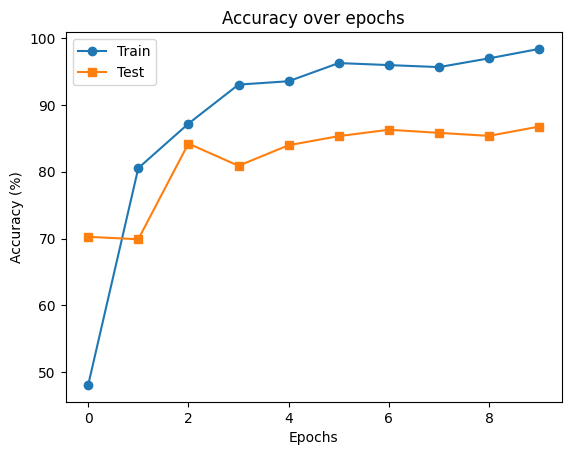

In [238]:
# Run the model without changing the weights; this will be the baseline performance.
# Notice the model creation is outside the training
net_base,lossfun,optimizer = mnist_1()
gaussian_weights(model_1, mean=0, std=10)
trainAcc_base,testAcc_base,losses,net_base = train_1(net_base,lossfun,optimizer)

# plot the results
plt.plot(range(len(trainAcc_base)),trainAcc_base,'o-', range(len(testAcc_base)),testAcc_base ,'s-')
plt.legend(['Train','Test'])
plt.title('Accuracy over epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.show()

In [60]:
# Change the weights before training
net_zero,lossfun,optimizer = mnist_1()

# set to zeros
net_zero.fc1.weight.data = torch.zeros_like( net_zero.fc1.weight )

# confirm
net_zero.fc1.weight.data

tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.]])

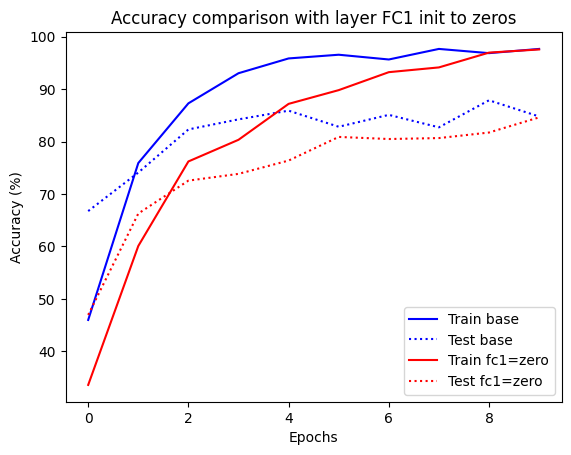

In [61]:
# run the model and show the results
trainAcc_zero,testAcc_zero,losses,net_zero = train_1(net_zero,lossfun,optimizer)

plt.plot(range(len(trainAcc_base)),trainAcc_base,'b-', range(len(testAcc_base)),testAcc_base ,'b:')
plt.plot(range(len(trainAcc_zero)),trainAcc_zero,'r-', range(len(testAcc_zero)),testAcc_zero ,'r:')
plt.legend(['Train base','Test base','Train fc1=zero','Test fc1=zero'])
plt.title('Accuracy comparison with layer FC1 init to zeros')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.show()

tensor([[ 0.1769, -0.0729,  0.2990,  ...,  0.6374,  0.1095,  0.3136],
        [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
        [ 0.1265, -0.0281,  0.0010,  ...,  0.0218, -0.1198, -0.0696],
        ...,
        [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000]])


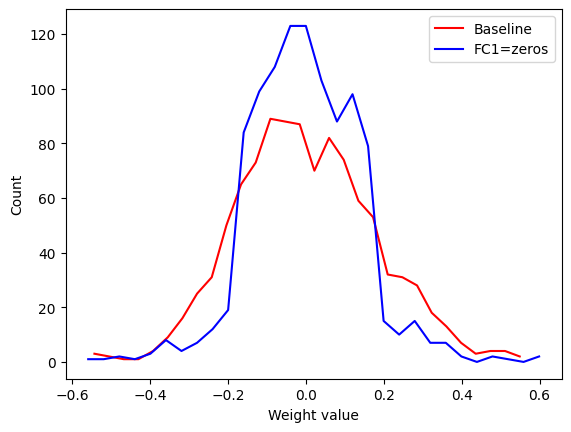

In [62]:
# Are the weights still zeros?
print(net_zero.fc1.weight.data)

# show the distributions in a histogram
y,x = np.histogram(net_base.fc2.weight.data.flatten(),30)
plt.plot((x[1:]+x[:-1])/2,y,'r',label='Baseline')

y,x = np.histogram(net_zero.fc2.weight.data.flatten(),30)
plt.plot((x[1:]+x[:-1])/2,y,'b',label='FC1=zeros')

plt.legend()
plt.xlabel('Weight value')
plt.ylabel('Count')
plt.show()

Additional Iterations

(10000, 784) (10000,)
(1000, 784) (1000,)
label of image in row no 763 : 6


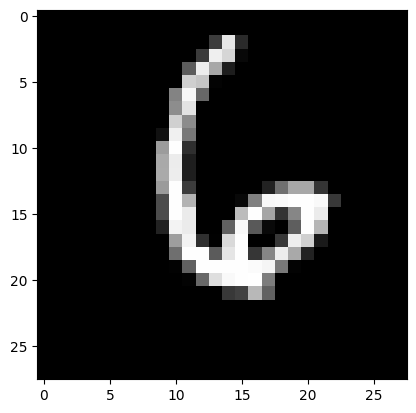

In [2]:
loader = MNISTLoader()
images, labels = loader.load()
test_images, test_labels = loader.load(train=False)
train_images, train_labels = loader.load(train=True)

#for grokking
#train_images = train_images[0:1000]
#train_labels = train_labels[0:1000]

train_images = train_images[0:1000]
train_labels = train_labels[0:1000]

print(test_images.shape, test_labels.shape)
print(train_images.shape, train_labels.shape)

type(train_images), type(train_labels)

i = 763
print(f"label of image in row no {i} :", int(train_labels[i-1]))
plt.imshow(train_images[i-1].reshape(28,28), cmap='gray')

In [3]:
print(f"Train data (Pre Normalization) : data min value {train_images.min()}, data max value {train_images.max()}")
print(f"Test data (not normalized) : data min value {test_images.min()}, data max value {test_images.max()}")

#normalize data
trainNorm = train_images/train_images.max()
print(f"\nTrain data (Post Normalization) : data min value {trainNorm.min()}, data max value {trainNorm.max()}")

testNorm = test_images/test_images.max()
print(f"Test data (Post Normalization) : data min value {testNorm.min()}, data max value {testNorm.max()}")

#convert to tensor
trainNorm_ts = torch.tensor(trainNorm).float()
trainLabels_ts = torch.tensor(train_labels).long() # Convert labels to long type (integer)
print(f"\ntrainNorm_ts shape : {trainNorm_ts.shape}, trainLabels_ts shape : {trainLabels_ts.shape}")

testNorm_ts = torch.tensor(testNorm).float()
testLabels_ts = torch.tensor(test_labels).long() # Convert labels to long type (integer)
print(f"testNorm_ts shape : {testNorm_ts.shape}, testLabels_ts shape : {testLabels_ts.shape}")

#train test split
#train_data,test_data, train_labels,test_labels = train_test_split(dataT, labelsT, test_size=.1)
#print(train_data.shape, train_labels.shape)
#print(test_data.shape, test_labels.shape)

#convert into PyTorch Datasets
train_data = torch.utils.data.TensorDataset(trainNorm_ts, trainLabels_ts)
test_data  = torch.utils.data.TensorDataset(testNorm_ts, testLabels_ts)

#dataloader objects
batchsize    = 32
train_loader = DataLoader(train_data,batch_size=batchsize,shuffle=True,drop_last=True)
test_loader  = DataLoader(test_data,batch_size=test_data.tensors[0].shape[0])

Train data (Pre Normalization) : data min value 0, data max value 255
Test data (not normalized) : data min value 0, data max value 255

Train data (Post Normalization) : data min value 0.0, data max value 1.0
Test data (Post Normalization) : data min value 0.0, data max value 1.0

trainNorm_ts shape : torch.Size([1000, 784]), trainLabels_ts shape : torch.Size([1000])
testNorm_ts shape : torch.Size([10000, 784]), testLabels_ts shape : torch.Size([10000])


In [4]:
class mnsit_class(nn.Module):
  def __init__(self):
    super().__init__()
    '''model architecture'''

    ### input layer
    self.input = nn.Linear(784,64)

    ### hidden layer
    self.fc1 = nn.Linear(64,32)
    self.fc2 = nn.Linear(32,32)

    ### output layer
    self.output = nn.Linear(32,10)

  # forward pass
  def forward(self,x):
    '''forward pass'''
    x = F.relu( self.input(x) )
    x = F.relu( self.fc1(x) )
    x = F.relu( self.fc2(x) )
    return self.output(x)
  
def model_init_1():
  ''' initialize model architecture, loss function and optimizer   '''
  net = mnsit_class()
  lossfun = nn.CrossEntropyLoss()
  optimizer = torch.optim.Adam(net.parameters(),lr=.01)

  return net,lossfun,optimizer 

def train_model_1(net,loss,optimizer):
  '''training loop'''

  # number of epochs
  numepochs = 10

  # initialize losses
  losses    = torch.zeros(numepochs)
  trainAcc  = []
  testAcc   = []

  # loop over epochs
  for epochi in range(numepochs):

    # switch on train mode
    net.train()

    # loop over training data batches
    batchAcc  = []
    batchLoss = []
    for X,y in train_loader:

      # forward pass and loss
      yHat = net(X)
      loss = lossfun(yHat,y)

      # backprop
      optimizer.zero_grad()
      loss.backward()
      optimizer.step()

      # loss from this batch
      batchLoss.append(loss.item())

      # compute accuracy
      matches = torch.argmax(yHat,axis=1) == y     # booleans (false/true)
      matchesNumeric = matches.float()             # convert to numbers (0/1)
      accuracyPct = 100*torch.mean(matchesNumeric) # average and x100
      batchAcc.append( accuracyPct )               # add to list of accuracies
    # end of batch loop...

    # now that we've trained through the batches, get their average training accuracy
    trainAcc.append( np.mean(batchAcc) )

    # and get average losses across the batches
    losses[epochi] = np.mean(batchLoss)

    # test accuracy
    net.eval()
    X,y = next(iter(test_loader)) # extract X,y from test dataloader
    with torch.no_grad(): # deactivates autograd
      yHat = net(X)

    testAcc.append( 100*torch.mean((torch.argmax(yHat,axis=1)==y).float()) )
  # end epochs

  return trainAcc,testAcc,losses,net

In [15]:
import time
stdevs = np.logspace(np.log10(0.0001), np.log10(10), 25)
bins = 80

accresults = np.zeros(len(stdevs))
histodata = np.zeros((len(stdevs), 2, bins))

startime = time.time()

for i, std in enumerate(stdevs):
    # Initialize model, loss function, and optimizer
    net, lossfun, optimizer = model_init_1()

    # Initialize weights with Gaussian distribution
    with torch.no_grad():
        for p in net.named_parameters():
            if 'weight' in p[0]:
                p[1].copy_(torch.randn_like(p[1]) * std)

    # Train the model
    trainAcc, testAcc, losses, net = train_model_1(net, lossfun, optimizer)

    # Store final test accuracy
    accresults[i] = np.mean(testAcc[-3:])  # Average of last 3 epochs for stability

    tmpparams = np.array([])
    for p in net.named_parameters():
        tmpparams = np.concatenate((tmpparams, p[1].data.numpy().flatten()), axis=0)

    y,x = np.histogram(tmpparams, bins=bins)
    histodata[i,0:] = (x[1:] + x[:-1])/2
    histodata[i,1:] = y

    time_elapsed = time.time() - startime
    print(f"finished {i+1}/{len(stdevs)} after {time_elapsed:.2f} seconds, model accuracy {accresults[i]:.2f}%")    


finished 1/25 after 2.42 seconds, model accuracy 10.64%
finished 2/25 after 5.14 seconds, model accuracy 28.48%
finished 3/25 after 7.94 seconds, model accuracy 30.64%
finished 4/25 after 10.77 seconds, model accuracy 51.76%
finished 5/25 after 13.31 seconds, model accuracy 65.37%
finished 6/25 after 16.21 seconds, model accuracy 41.72%
finished 7/25 after 18.69 seconds, model accuracy 73.22%
finished 8/25 after 21.08 seconds, model accuracy 81.16%
finished 9/25 after 23.40 seconds, model accuracy 79.91%
finished 10/25 after 26.07 seconds, model accuracy 80.59%
finished 11/25 after 28.47 seconds, model accuracy 77.83%
finished 12/25 after 30.65 seconds, model accuracy 83.30%
finished 13/25 after 32.81 seconds, model accuracy 83.20%
finished 14/25 after 35.22 seconds, model accuracy 84.61%
finished 15/25 after 37.42 seconds, model accuracy 86.74%
finished 16/25 after 39.58 seconds, model accuracy 86.34%
finished 17/25 after 41.60 seconds, model accuracy 83.71%
finished 18/25 after 44.15

Text(0.5, 1.0, 'Test Accuracy vs Std Dev of Initial Weights')

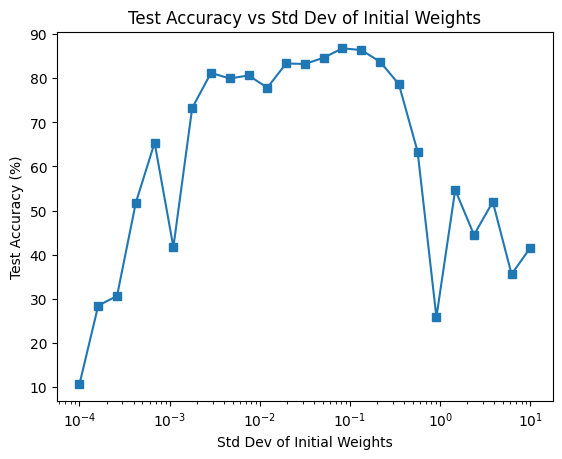

In [17]:
plt.plot(stdevs,accresults,'s-')
plt.xscale('log')
plt.xlabel('Std Dev of Initial Weights')    
plt.ylabel('Test Accuracy (%)')
plt.title('Test Accuracy vs Std Dev of Initial Weights')

Text(0.5, 1.0, 'Histogram of Final Weights for Different Initial Std Devs')

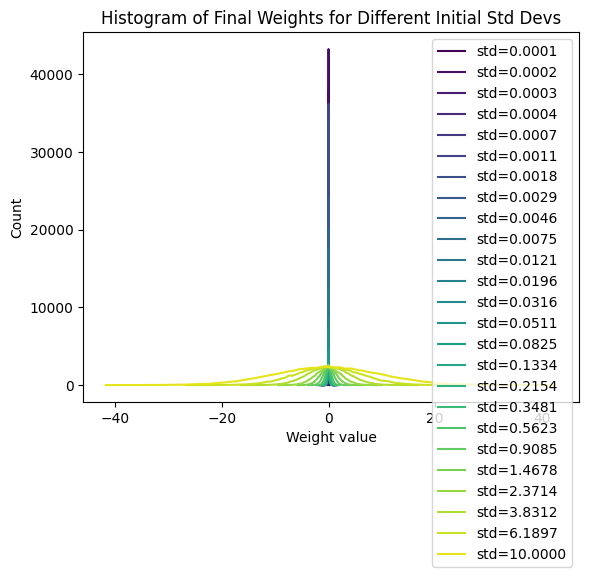

In [18]:
for i in range(len(stdevs)):
    plt.plot(histodata[i,0], histodata[i,1], label=f'std={stdevs[i]:.4f}', color=plt.cm.viridis(i/len(stdevs)))

plt.xlabel('Weight value')
plt.ylabel('Count')
plt.legend()
plt.title('Histogram of Final Weights for Different Initial Std Devs')